In [1]:
import os
import glob
import pandas as pd
import nibabel as nib
from nilearn import plotting
import matplotlib.pyplot as plt


data_dir = './data/1160600'

# --- 1. READING THE CLINICAL FILE ---
csv_file = os.path.join(data_dir, 'cobre_model_group.csv')
if os.path.exists(csv_file):
    df_labels = pd.read_csv(csv_file)
    print("Overview of the clinical data(first 5 rows):")
    display(df_labels.head())
    display(df_labels.shape)
    display(df_labels.columns)
    display(df_labels.info())
    df_labels.columns = df_labels.columns.str.strip()
    print("les valeurs sont: \n")  # Remove any leading/trailing whitespace from column names
    print(df_labels['sz'].value_counts())
    display(df_labels.iloc[72:])
    
else:
    print("Warning: csv file not found.")
    

Overview of the clinical data(first 5 rows):


,,sz,age,sex,FD
0,szxxx0040000,1.0,20.0,1.0,0.18
1,szxxx0040001,1.0,27.0,0.0,0.50
2,szxxx0040002,1.0,19.0,0.0,0.21
3,szxxx0040003,1.0,28.0,0.0,0.23
4,szxxx0040004,1.0,55.0,0.0,0.14


(146, 5)

Index([' ', 'sz ', 'age ', 'sex ', 'FD'], dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0           146 non-null    object 
 1   sz      146 non-null    float64
 2   age     146 non-null    float64
 3   sex     146 non-null    float64
 4   FD      146 non-null    float64
dtypes: float64(4), object(1)
memory usage: 5.8+ KB


None

les valeurs sont: 

sz
0.0    74
1.0    72
Name: count, dtype: int64


,,sz,age,sex,FD
72,contxxx0040013,0.0,34.0,0.0,0.18
73,contxxx0040014,0.0,31.0,0.0,0.30
74,contxxx0040017,0.0,30.0,1.0,0.25
75,contxxx0040018,0.0,47.0,0.0,0.19
76,contxxx0040019,0.0,44.0,0.0,0.20
...,...,...,...,...,...
141,contxxx0040140,0.0,53.0,1.0,0.25
142,contxxx0040141,0.0,35.0,1.0,0.22
143,contxxx0040144,0.0,54.0,0.0,0.30
144,contxxx0040146,0.0,39.0,0.0,0.19



 Number of irmF images found: 146
 test file selected: fmri_contxxx0040048_session1_run1.nii.gz

Loading the first image for sanity check...
 Dimensions of 4D matrix (X, Y, Z, T): (53, 64, 52, 127)


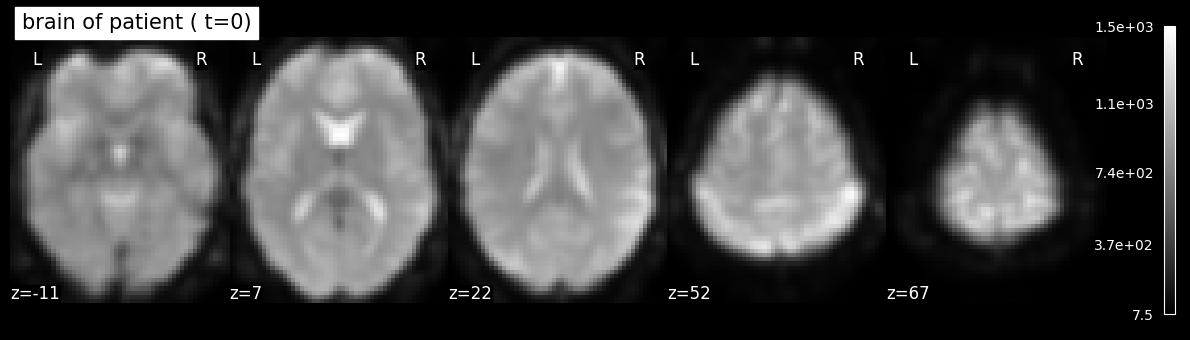

In [2]:
# --- 2. select first subject and sanity check ---
patient_files = glob.glob(os.path.join(data_dir, '*.nii.gz'))
print(f"\n Number of irmF images found: {len(patient_files)}")

if len(patient_files) > 0:
    test_file = patient_files[0]
    print(f" test file selected: {os.path.basename(test_file)}")

    # --- 3. sanity check: load and visualize the first image ---
    print("\nLoading the first image for sanity check...")
    img = nib.load(test_file)
    print(f" Dimensions of 4D matrix (X, Y, Z, T): {img.shape}")

    # we extract the first image from the film (time point 0)
    first_volume = img.slicer[..., 0]

    # we display the brain with nilearn
    plotting.plot_epi(first_volume, 
                      title="brain of patient ( t=0)", 
                      display_mode='z', #horizontal slices 
                      cut_coords=5, # number of slices to display
                      cmap='gray') # gray levels
    plt.show()
else:
    print("No patient files found in the data directory.")

In [4]:
# --- 4. Masking preparation (schaefer atlas 200) ---
import numpy as np
from nilearn import image, datasets
from nilearn.maskers import NiftiLabelsMasker

print("\nLoading the Schaefer atlas (200 parcels)...")

dset_schaefer_200 = datasets.fetch_atlas_schaefer_2018(n_rois=200, resolution_mm=2)
dset_ho = datasets.fetch_atlas_harvard_oxford('sub-maxprob-thr25-2mm') #21 rois


#load the harvard oxford atlas and create masker
if not isinstance(dset_ho.maps, str):
    original_img = dset_ho.maps
else:
    import nibabel as nib
    original_img = nib.load(dset_ho.maps)

clean_data = original_img.get_fdata().copy()



# delete region 1 and 2 (Cortex/White Matter global)
# set to 0 every pixels that belong to these labels. 
clean_data[clean_data == 1] = 0
clean_data[clean_data == 2] = 0

#create new clean atlas image 
cleaned_img = image.new_img_like(original_img, clean_data)

# MASKERS

masker_schaefer = NiftiLabelsMasker(labels_img=dset_schaefer_200.maps, 
#standadize with z-score normalization to avoid biais in the glasso penality, and due to the arbitrary units of fmri
                                    standardize='zscore_sample', 
                                    memory='nilearn_cache', verbose=0)
#same arguments for the subcortical atlas
masker_subcort = NiftiLabelsMasker(labels_img=cleaned_img,
                                    standardize='zscore_sample',
                                    memory='nilearn_cache', verbose=0)
print("Atlases loaded and maskers created. (Schaefer 200 parcels and Harvard-Oxford subcortical atlas 21 parcels)")



Loading the Schaefer atlas (200 parcels)...


[fetch_atlas_schaefer_2018] Dataset found in /home/mathi/nilearn_data/schaefer_2018

[fetch_atlas_harvard_oxford] Dataset found in /home/mathi/nilearn_data/fsl

Atlases loaded and maskers created. (Schaefer 200 parcels and Harvard-Oxford subcortical atlas 21 parcels)


In [ ]:
import numpy as np
import h5py #for database storage
from sklearn.covariance import GraphicalLassoCV
from tqdm.notebook import tqdm
from sklearn.preprocessing import StandardScaler
import os

#Initialisation of lists to store matrices
hc_matrices_list = []
scz_matrices_list = []

print(f" Start processing for {len(patient_files)} patients...")

# Glasso configuration (cv=3 for faster computation, n_jobs=-1 to use all CPU cores)
glasso=GraphicalLassoCV(cv=3, n_jobs=-1, max_iter=1000, tol=1e-2)

#loop over all .nii.gz files
for file_path in tqdm(patient_files, desc="IRM processing"):
    try:
        # 1. Time-serie extraction (time x (200 ROI + 21 subcortical ROIs))
        ts_schaefer = masker_schaefer.fit_transform(file_path)
        ts_subcort = masker_subcort.fit_transform(file_path)

        # Concatenate the time series from both atlases
        time_series = np.hstack([ts_schaefer, ts_subcort])

        # --- ROBUST SECURITY ---
        # --- check if there are some NaNs values and clean them
        time_series = np.nan_to_num(time_series, nan=0.0)

        # handling dead columns (null variance)
        # necessary to avoid issues with Glasso, which cannot handle features with zero variance.
        std_devs = np.std(time_series, axis=0)
        dead_cols = std_devs < 1e-6

        if np.any(dead_cols):
            # jitter injection to stabilize Glasso
            noise = np.random.normal(0, 1e-7, size=(time_series.shape[0], np.sum(dead_cols)))
            time_series[:, dead_cols] = noise

        

        # check  if there are some NaN values or inf values in the time series, which can cause issues with Glasso
        if not np.isfinite(time_series).all():
            print(f"Skipping {os.path.basename(file_path)} due to NaN or inf values in the time series.")
            continue

        scaler = StandardScaler()
        time_series = scaler.fit_transform(time_series)

        # SÉCURITÉ SUPPLÉMENTAIRE : On re-nettoie après le scaler
        time_series = np.nan_to_num(time_series, nan=0.0)
   

        # 2. Glasso computation
        glasso.fit(time_series)
        precision_matrix = glasso.precision_.copy() # we copy the precision matrix to avoid modifying the original one

        # 3. 0 initialisation of the diagonal (self-connections)
        np.fill_diagonal(precision_matrix, 0)

        # 4. Sort patient (HC vs SCZ), file name contains contxxx for controls and szxxx for patients
        file_name = os.path.basename(file_path)
        if 'contxxx' in file_name:
            hc_matrices_list.append(precision_matrix)
        elif 'szxxx' in file_name:
            scz_matrices_list.append(precision_matrix)
    except Exception as e:
        print(f"Error with file {file_path}: {e}")

# convert lists to "cubes" (3D numpyarrays: number of patients x 221 x 221)
hc_array = np.array(hc_matrices_list)
scz_array = np.array(scz_matrices_list)

print(f"\n Calculation completed! Final dimensions:")
print(f"Healthy controls (HC): {hc_array.shape}")
print(f"Schizophrenia patients (SCZ): {scz_array.shape}")

# ---------------------------------------------------
# CREATION OF A DATABASE WITH HDF5 (DATA PERSISTENCE)
# ---------------------------------------------------


db_path = 'cobre_connectomes_database.h5'

# opening/creating HDF5 file in write mode
with h5py.File(db_path, 'w') as db:
    #creating two datasets for HC and SCZ
    db.create_dataset('hc_matrices', data=hc_array, compression='gzip')
    db.create_dataset('scz_matrices', data=scz_array, compression='gzip')

    # adding metadata as attributes
    db.attrs['description'] = 'Database of GLasso connectomes (Atlas Schaefer 200 + Harvard-Oxford subcortical) for COBRE dataset'
    db.attrs['number_of_hc'] = hc_array.shape[0]
    db.attrs['number_of_scz'] = scz_array.shape[0]

print(f"\n Database created successfully at: {db_path} !")



 Start processing for 146 patients...


IRM processing:   0%|          | 0/146 [00:00<?, ?it/s]

/home/mathi/miniconda3/lib/python3.12/site-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/home/mathi/miniconda3/lib/python3.12/site-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/home/mathi/miniconda3/lib/python3.12/site-packages/sklearn/covariance/_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 500 iteration: dual gap: -3.810e-02
  warnings.warn(
/home/mathi/miniconda3/lib/python3.12/site-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


KeyboardInterrupt: 

Keys in the database: ['hc_matrices', 'scz_matrices']
HC data shape: (71, 221, 221)


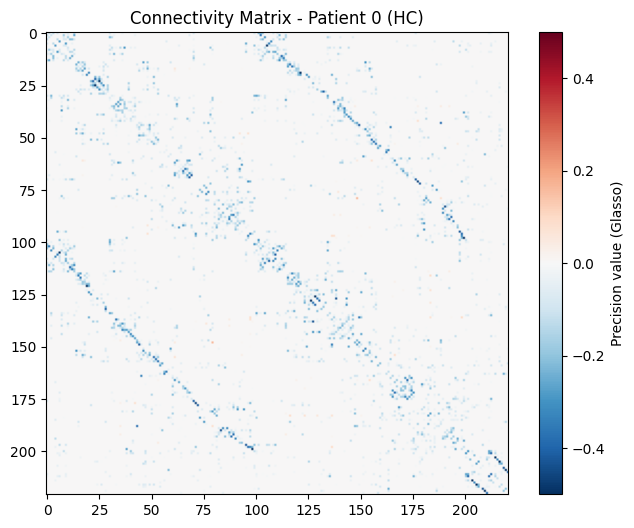

In [5]:
import h5py
import matplotlib.pyplot as plt

# Path to your database
db_path = 'cobre_connectomes_database.h5'

with h5py.File(db_path, 'r') as db:
    #List all keys to see what's inside the database
    print("Keys in the database:", list(db.keys()))

    #Load the HC (healthy control) array
    hc_data = db['hc_matrices'][:]

    #check dimensions (Patients, ROIs, ROIs)
    print(f"HC data shape: {hc_data.shape}")

    # Visualize the first patient's connectivity matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(hc_data[0], cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    plt.colorbar(label='Precision value (Glasso)')
    plt.title("Connectivity Matrix - Patient 0 (HC)")
    plt.show()
    

file verification: ./data/1160600/fmri_contxxx0040048_session1_run1.nii.gz


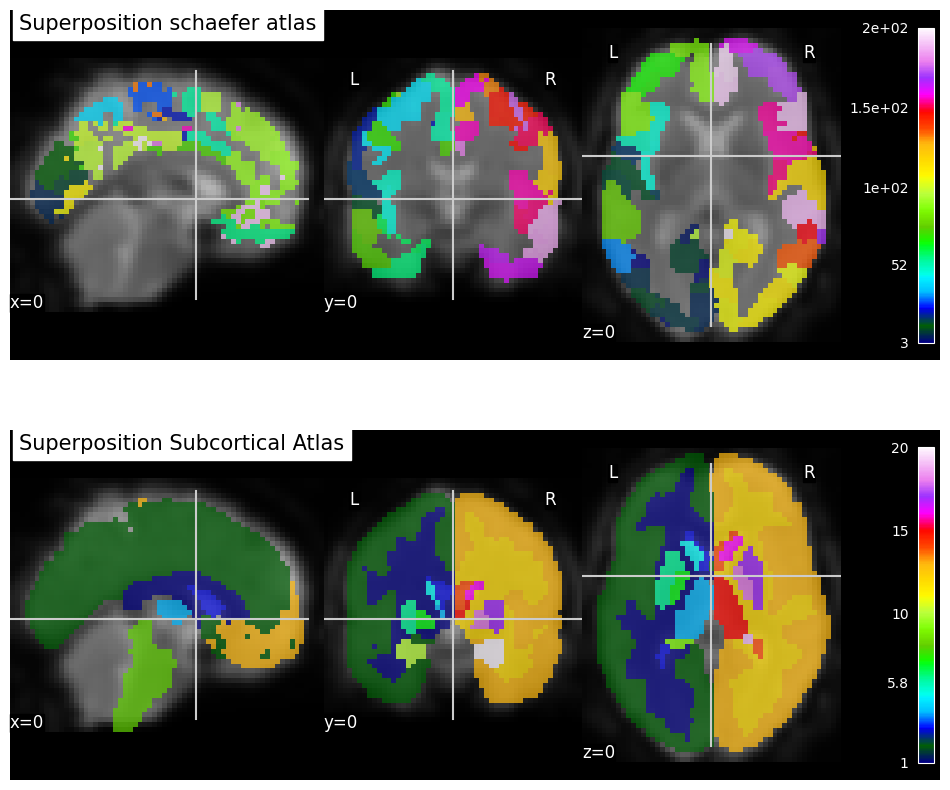

In [7]:
from nilearn import plotting, image
import matplotlib.pyplot as plt

# 1. chosen patient file for visualization (first one in the list (default))
sample_patient = patient_files[0] # we can change the index to visualize another patient if we want

print(f"file verification: {sample_patient}")

#2. load the image (mean accross time for better visualization)
mean_img = image.mean_img(sample_patient)

img_schaefer = masker_schaefer.labels_img_
img_subcort = masker_subcort.labels_img_

#3. figure configuration
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

#visualisation of the schaefer atlas (cortex)
plotting.plot_roi(img_schaefer, bg_img=mean_img,
                  title="Superposition schaefer atlas", 
                  display_mode='ortho', cut_coords=(0, 0, 0), 
                  axes=axes[0])

# visualisation of the subcortical atlas
plotting.plot_roi(img_subcort, bg_img=mean_img, 
                  title="Superposition Subcortical Atlas", 
                  display_mode='ortho', cut_coords=(0, 0, 0), 
                  axes=axes[1])

plt.show()